# Predictive Modeling: Flight Delay Classification & Regression

**Goal**: Predict whether an airport-airline-month record will have high delays (classification) and predict average delay severity (regression).  
**Approach**: Baseline models first, then secondary (improved) models, with full evaluation on both.

| Task | Target | Metric |
|------|--------|--------|
| Classification | `is_high_delay` (delay_rate > 20%) | Accuracy, Precision, Recall, F1 |
| Regression | `avg_delay_per_delayed_flight` | MAE, RMSE, R² |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.svm import SVC, SVR

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('dataset/cleaned_flight_data.csv')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (135293, 34)


,year,month,carrier,airline,airport,airport_full_name,total_flights,delayed_flights,carrier_delay_count,weather_delay_count,...,avg_delay_per_delayed_flight,season,quarter,is_high_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_aircraft_delay_pct,dominant_delay_cause
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,69.068966,Winter,4,1,51.123315,0.599101,9.585622,0.0,38.691962,carrier
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,87.357143,Winter,4,1,40.147179,11.120196,1.062960,0.0,47.669665,late_aircraft
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,83.153846,Winter,4,1,27.197040,1.526364,9.481961,0.0,61.794635,late_aircraft


## Data Preparation
Select features that are **available before knowing the outcome**  operational context, not delay results.

In [3]:
# Encode categorical features
le_carrier = LabelEncoder()
le_airport = LabelEncoder()
le_season = LabelEncoder()

df['carrier_enc'] = le_carrier.fit_transform(df['carrier'])
df['airport_enc'] = le_airport.fit_transform(df['airport'])
df['season_enc'] = le_season.fit_transform(df['season'])

# Features: operational context available before delays are known
FEATURE_COLS = [
    'year', 'month', 'quarter', 'season_enc',
    'carrier_enc', 'airport_enc',
    'total_flights', 'cancelled_flights', 'diverted_flights'
]

# Targets
y_class = df['is_high_delay']
y_reg = df['avg_delay_per_delayed_flight']
X = df[FEATURE_COLS]

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Classification target balance: {y_class.value_counts().to_dict()}')
print(f'Regression target range: {y_reg.min():.1f} — {y_reg.max():.1f} (mean: {y_reg.mean():.1f})')

Features: 9 | Samples: 135293
Classification target balance: {0: 83280, 1: 52013}
Regression target range: 0.0 — 3174.0 (mean: 61.9)


In [4]:
# Train-test split (same split for both tasks)
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 108234 | Test: 27059


In [5]:
# Helper: evaluate classification model
def eval_classifier(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        '_model': model, '_y_pred': y_pred
    }

# Helper: evaluate regression model
def eval_regressor(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_te, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'R2': r2_score(y_te, y_pred),
        '_model': model, '_y_pred': y_pred
    }

# Section A: Baseline Models
Simple, interpretable models as a performance floor.

| Task | Baseline Model |
|------|----------------|
| Classification | Logistic Regression, Decision Tree |
| Regression | Ridge Regression, Decision Tree Regressor |

### A1. Baseline Classification

In [6]:
baseline_cls_results = []

# Logistic Regression (needs scaled data)
baseline_cls_results.append(eval_classifier(
    'Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, X_test_sc, y_cls_train, y_cls_test
))

# Decision Tree
baseline_cls_results.append(eval_classifier(
    'Decision Tree', DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    X_train, X_test, y_cls_train, y_cls_test
))

baseline_cls_df = pd.DataFrame(baseline_cls_results).drop(columns=['_model', '_y_pred'])
print('BASELINE CLASSIFICATION RESULTS')
baseline_cls_df.round(4)

BASELINE CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6457,0.5614,0.3586,0.4377
1,Decision Tree,0.7347,0.6659,0.6220,0.6432


In [ ]:
# Confusion matrices for baselines
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, res in enumerate(baseline_cls_results):
    ConfusionMatrixDisplay.from_predictions(
        y_cls_test, res['_y_pred'], ax=axes[idx],
        cmap='Blues', colorbar=False
    )
    axes[idx].set_title(f"{res['Model']}\nF1={res['F1']:.3f}")
plt.suptitle('Baseline Classification — Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/baseline_cls_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### A2. Baseline Regression

In [7]:
baseline_reg_results = []

# Ridge Regression (needs scaled data)
baseline_reg_results.append(eval_regressor(
    'Ridge Regression', Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_reg_train, y_reg_test
))

# Decision Tree Regressor
baseline_reg_results.append(eval_regressor(
    'Decision Tree Regressor', DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    X_train, X_test, y_reg_train, y_reg_test
))

baseline_reg_df = pd.DataFrame(baseline_reg_results).drop(columns=['_model', '_y_pred'])
print('BASELINE REGRESSION RESULTS')
baseline_reg_df.round(4)

BASELINE REGRESSION RESULTS


,Model,MAE,RMSE,R2
0,Ridge Regression,24.2033,41.9469,0.0244
1,Decision Tree Regressor,21.8655,45.4820,-0.1469


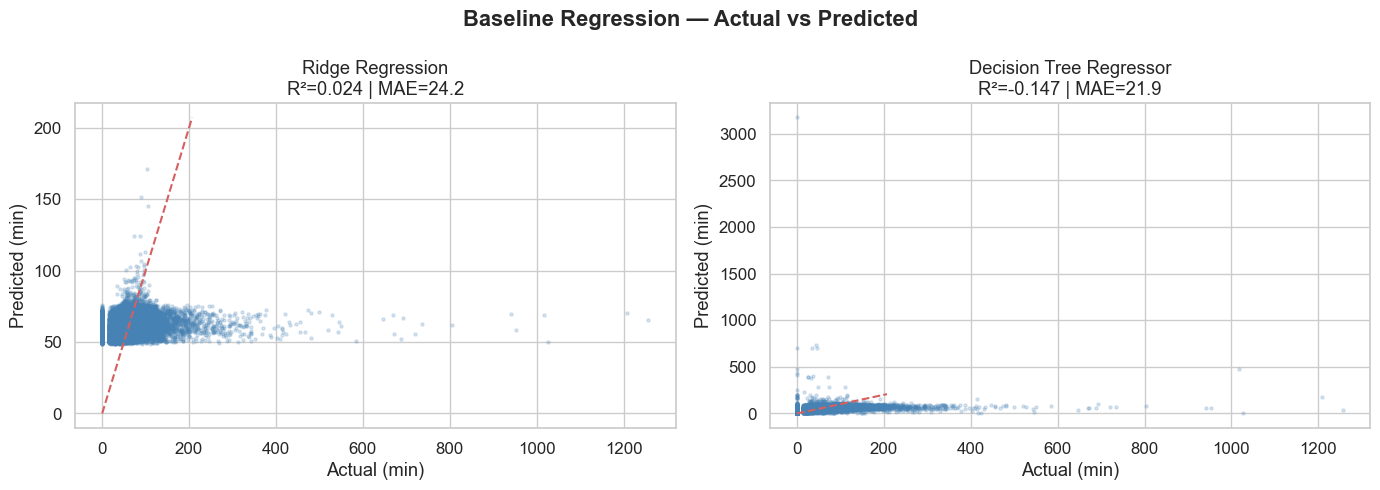

In [8]:
# Actual vs Predicted scatter for baselines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, res in enumerate(baseline_reg_results):
    axes[idx].scatter(y_reg_test, res['_y_pred'], alpha=0.2, s=5, color='steelblue')
    lims = [0, min(y_reg_test.max(), np.percentile(y_reg_test, 99))]
    axes[idx].plot(lims, lims, 'r--', linewidth=1.5)
    axes[idx].set_xlabel('Actual (min)')
    axes[idx].set_ylabel('Predicted (min)')
    axes[idx].set_title(f"{res['Model']}\nR²={res['R2']:.3f} | MAE={res['MAE']:.1f}")
plt.suptitle('Baseline Regression — Actual vs Predicted', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/baseline_reg_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Section B: Secondary Models (Ensemble)
More powerful models to improve over baselines.

| Task | Secondary Model |
|------|----------------|
| Classification | Random Forest, Gradient Boosting |
| Regression | Random Forest, Gradient Boosting |

### B1. Secondary Classification

In [9]:
secondary_cls_results = []

# Random Forest
secondary_cls_results.append(eval_classifier(
    'Random Forest', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, X_test, y_cls_train, y_cls_test
))

# Gradient Boosting
secondary_cls_results.append(eval_classifier(
    'Gradient Boosting', GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE),
    X_train, X_test, y_cls_train, y_cls_test
))

secondary_cls_df = pd.DataFrame(secondary_cls_results).drop(columns=['_model', '_y_pred'])
print('SECONDARY CLASSIFICATION RESULTS')
secondary_cls_df.round(4)

SECONDARY CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.7657,0.7237,0.6319,0.6747
1,Gradient Boosting,0.7725,0.7334,0.6413,0.6842


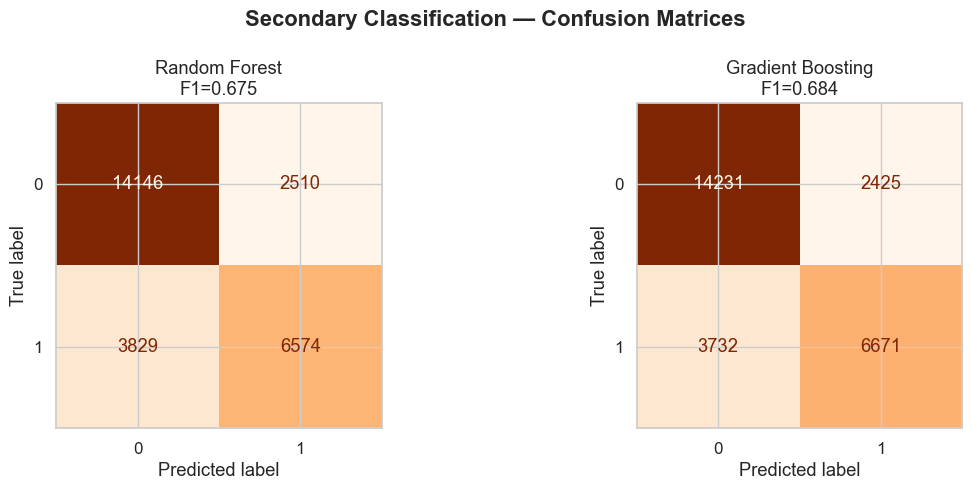

In [10]:
# Confusion matrices for secondary
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, res in enumerate(secondary_cls_results):
    ConfusionMatrixDisplay.from_predictions(
        y_cls_test, res['_y_pred'], ax=axes[idx],
        cmap='Oranges', colorbar=False
    )
    axes[idx].set_title(f"{res['Model']}\nF1={res['F1']:.3f}")
plt.suptitle('Secondary Classification — Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/secondary_cls_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### B2. Secondary Regression

In [11]:
secondary_reg_results = []

# Random Forest Regressor
secondary_reg_results.append(eval_regressor(
    'Random Forest Regressor', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, X_test, y_reg_train, y_reg_test
))

# Gradient Boosting Regressor
secondary_reg_results.append(eval_regressor(
    'Gradient Boosting Regressor', GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE),
    X_train, X_test, y_reg_train, y_reg_test
))

secondary_reg_df = pd.DataFrame(secondary_reg_results).drop(columns=['_model', '_y_pred'])
print('SECONDARY REGRESSION RESULTS')
secondary_reg_df.round(4)

SECONDARY REGRESSION RESULTS


,Model,MAE,RMSE,R2
0,Random Forest Regressor,21.2371,40.2267,0.1028
1,Gradient Boosting Regressor,20.9560,39.8638,0.1189


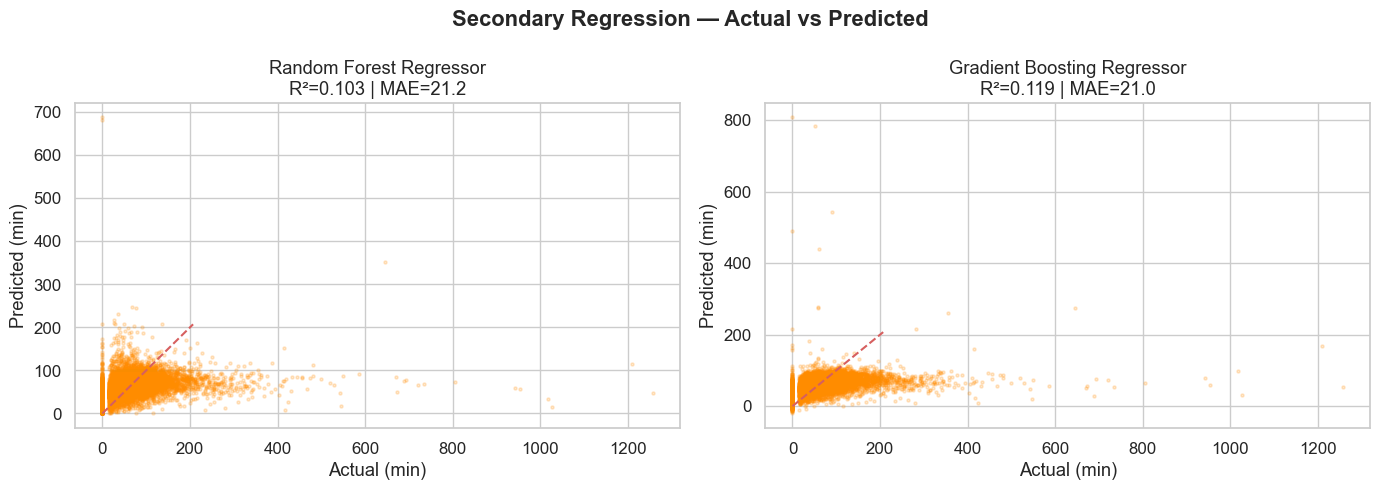

In [12]:
# Actual vs Predicted scatter for secondary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, res in enumerate(secondary_reg_results):
    axes[idx].scatter(y_reg_test, res['_y_pred'], alpha=0.2, s=5, color='darkorange')
    lims = [0, min(y_reg_test.max(), np.percentile(y_reg_test, 99))]
    axes[idx].plot(lims, lims, 'r--', linewidth=1.5)
    axes[idx].set_xlabel('Actual (min)')
    axes[idx].set_ylabel('Predicted (min)')
    axes[idx].set_title(f"{res['Model']}\nR²={res['R2']:.3f} | MAE={res['MAE']:.1f}")
plt.suptitle('Secondary Regression — Actual vs Predicted', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/secondary_reg_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Baseline vs Secondary: Head-to-Head Comparison

CLASSIFICATION — ALL MODELS
     Type               Model  Accuracy  Precision  Recall     F1
 Baseline Logistic Regression    0.6457     0.5614  0.3586 0.4377
 Baseline       Decision Tree    0.7347     0.6659  0.6220 0.6432
Secondary       Random Forest    0.7657     0.7237  0.6319 0.6747
Secondary   Gradient Boosting    0.7725     0.7334  0.6413 0.6842


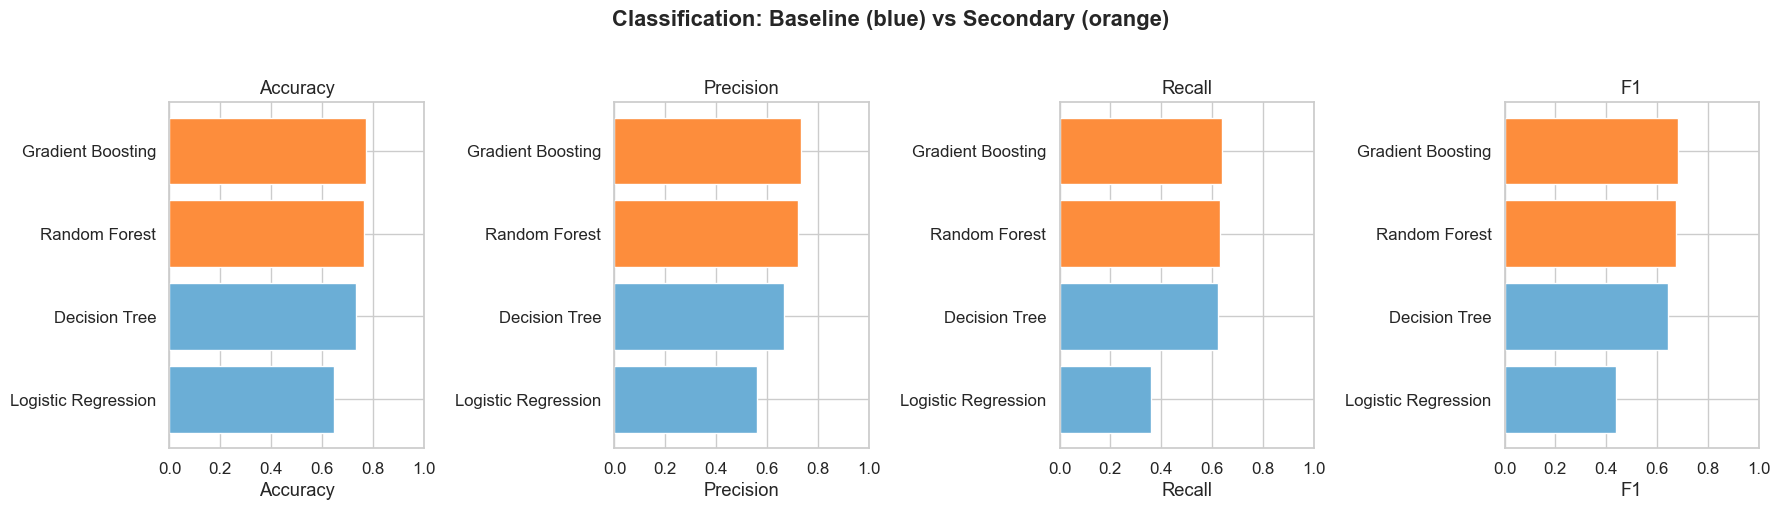

In [13]:
# Classification comparison
all_cls = pd.concat([baseline_cls_df, secondary_cls_df], ignore_index=True)
all_cls['Type'] = ['Baseline', 'Baseline', 'Secondary', 'Secondary']
all_cls = all_cls[['Type', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1']]

print('CLASSIFICATION — ALL MODELS')
print(all_cls.round(4).to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1']):
    colors = ['#6baed6', '#6baed6', '#fd8d3c', '#fd8d3c']
    axes[idx].barh(all_cls['Model'], all_cls[metric], color=colors)
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(metric)
    axes[idx].set_xlim(0, 1)
plt.suptitle('Classification: Baseline (blue) vs Secondary (orange)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/cls_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

REGRESSION — ALL MODELS
     Type                       Model     MAE    RMSE      R2
 Baseline            Ridge Regression 24.2033 41.9469  0.0244
 Baseline     Decision Tree Regressor 21.8655 45.4820 -0.1469
Secondary     Random Forest Regressor 21.2371 40.2267  0.1028
Secondary Gradient Boosting Regressor 20.9560 39.8638  0.1189


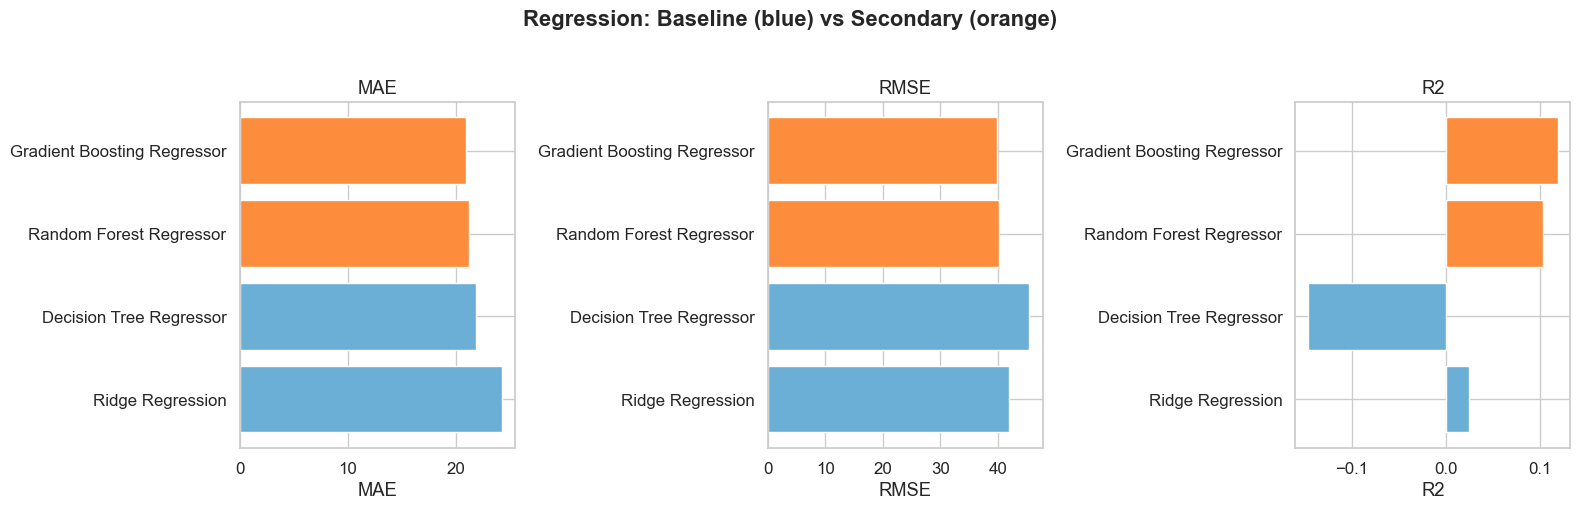

In [14]:
# Regression comparison
all_reg = pd.concat([baseline_reg_df, secondary_reg_df], ignore_index=True)
all_reg['Type'] = ['Baseline', 'Baseline', 'Secondary', 'Secondary']
all_reg = all_reg[['Type', 'Model', 'MAE', 'RMSE', 'R2']]

print('REGRESSION — ALL MODELS')
print(all_reg.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#6baed6', '#6baed6', '#fd8d3c', '#fd8d3c']
for idx, metric in enumerate(['MAE', 'RMSE', 'R2']):
    axes[idx].barh(all_reg['Model'], all_reg[metric], color=colors)
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(metric)
plt.suptitle('Regression: Baseline (blue) vs Secondary (orange)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/reg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Best Models)

In [15]:
# Pick best classifier and best regressor by their primary metrics
best_cls_res = max(baseline_cls_results + secondary_cls_results, key=lambda r: r['F1'])
best_reg_res = min(baseline_reg_results + secondary_reg_results, key=lambda r: r['MAE'])

print(f'Best classifier: {best_cls_res["Model"]} (F1={best_cls_res["F1"]:.4f})')
print(f'Best regressor:  {best_reg_res["Model"]} (MAE={best_reg_res["MAE"]:.2f})')

Best classifier: Gradient Boosting (F1=0.6842)
Best regressor:  Gradient Boosting Regressor (MAE=20.96)


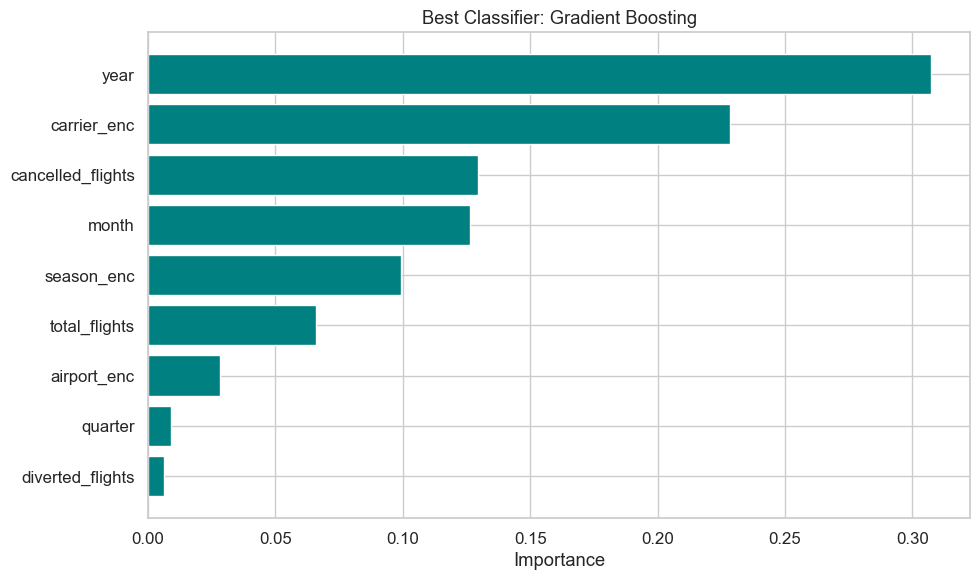

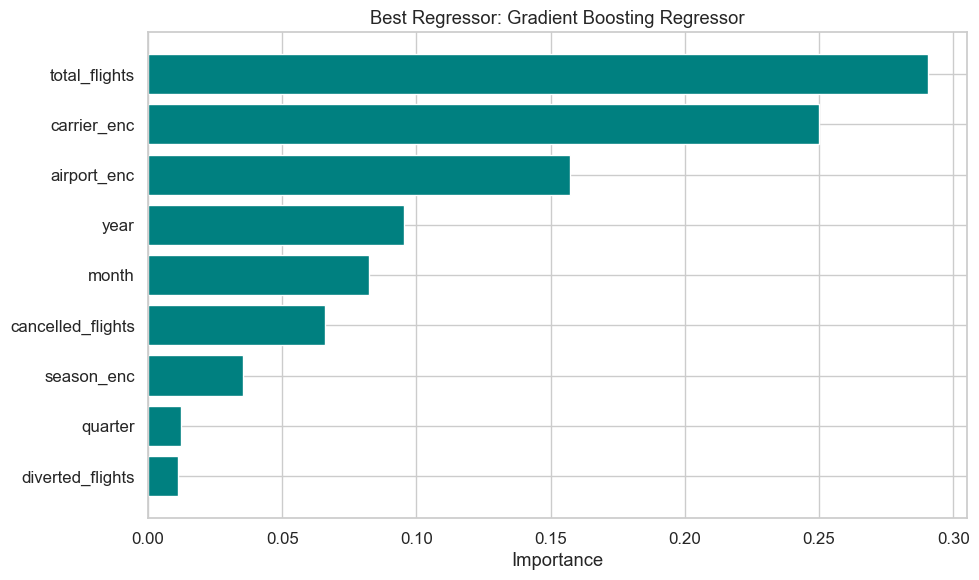

In [16]:
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_).flatten()
    else:
        print(f'No feature importance available for {title}')
        return
    
    fi = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi = fi.sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(fi['Feature'], fi['Importance'], color='teal')
    plt.xlabel('Importance')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'outputs/figures/feature_importance_{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fi

fi_cls = plot_feature_importance(best_cls_res['_model'], FEATURE_COLS, f'Best Classifier: {best_cls_res["Model"]}')
fi_reg = plot_feature_importance(best_reg_res['_model'], FEATURE_COLS, f'Best Regressor: {best_reg_res["Model"]}')

## Cross-Validation (Best Models)

In [17]:
# 5-fold CV on best models
cv_cls = cross_val_score(best_cls_res['_model'], X, y_class, cv=5, scoring='f1', n_jobs=-1)
cv_reg = cross_val_score(best_reg_res['_model'], X, y_reg, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

print(f'Best Classifier ({best_cls_res["Model"]}) — 5-Fold CV F1:')
print(f'  Folds: {cv_cls.round(4)}')
print(f'  Mean: {cv_cls.mean():.4f} ± {cv_cls.std():.4f}')

print(f'\nBest Regressor ({best_reg_res["Model"]}) — 5-Fold CV MAE:')
print(f'  Folds: {(-cv_reg).round(2)}')
print(f'  Mean: {-cv_reg.mean():.2f} ± {cv_reg.std():.2f}')

Best Classifier (Gradient Boosting) — 5-Fold CV F1:
  Folds: [5.554e-01 1.887e-01 6.780e-02 2.900e-03 2.000e-04]
  Mean: 0.1630 ± 0.2078

Best Regressor (Gradient Boosting Regressor) — 5-Fold CV MAE:
  Folds: [19.88 21.3  20.91 20.02 27.77]
  Mean: 21.98 ± 2.95


## Save Best Models & Results

In [18]:
# Save models
joblib.dump(best_cls_res['_model'], 'outputs/models/best_classifier.pkl')
joblib.dump(best_reg_res['_model'], 'outputs/models/best_regressor.pkl')
joblib.dump(scaler, 'outputs/models/feature_scaler.pkl')

# Save comparison tables
all_cls.to_csv('outputs/tables/classification_results.csv', index=False)
all_reg.to_csv('outputs/tables/regression_results.csv', index=False)

print('Saved to outputs/:')
print('  models/best_classifier.pkl')
print('  models/best_regressor.pkl')
print('  models/feature_scaler.pkl')
print('  tables/classification_results.csv')
print('  tables/regression_results.csv')

Saved to outputs/:
  models/best_classifier.pkl
  models/best_regressor.pkl
  models/feature_scaler.pkl
  tables/classification_results.csv
  tables/regression_results.csv
